# CO Brews Visualizer

In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="white")

In [2]:
# local copy of cobrews.json
with open("cobrews.json", "r", encoding="utf-8") as f:
    raw_data = json.load(f)

places = raw_data.get("places", [])
df = pd.DataFrame(places)

# Convert coordinate and elevation fields to numeric floats
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df["elevation"] = pd.to_numeric(df["elevation"], errors="coerce")

# Drop any rows with missing coordinates or elevation
df = df.dropna(subset=["latitude", "longitude", "elevation"])

print(f"Successfully loaded {len(df)} valid brewery coordinates!")
print(df)

Successfully loaded 141 valid brewery coordinates!
                   id team                                name  \
0         davemattcsu  t00          Steamworks Brewing Company   
1           vertumnal  t14                Floodstage Ale Works   
2               CFRPI  t20         Storm Peak Brewing Bus Stop   
3           Mrwood223  t27         New Belgium Brewing Company   
4         chrislesher  t12         Green Mountain Beer Company   
..                ...  ...                                 ...   
136      random_vidzs  t29                  Bulzomi Brewing Co   
137            phntml  t26                Big Thompson Brewery   
138          Zgourd19  t17          Tommyknocker Brewery & Pub   
139  codingissofunyay  t17         Black Shirt Brewing Company   
140      hazelkatie28  t28  Main Street Brewery and Restaurant   

          municipality   latitude   longitude  elevation netid  \
0              Durango  37.278887 -107.873908       6529   NaN   
1             Brighton  

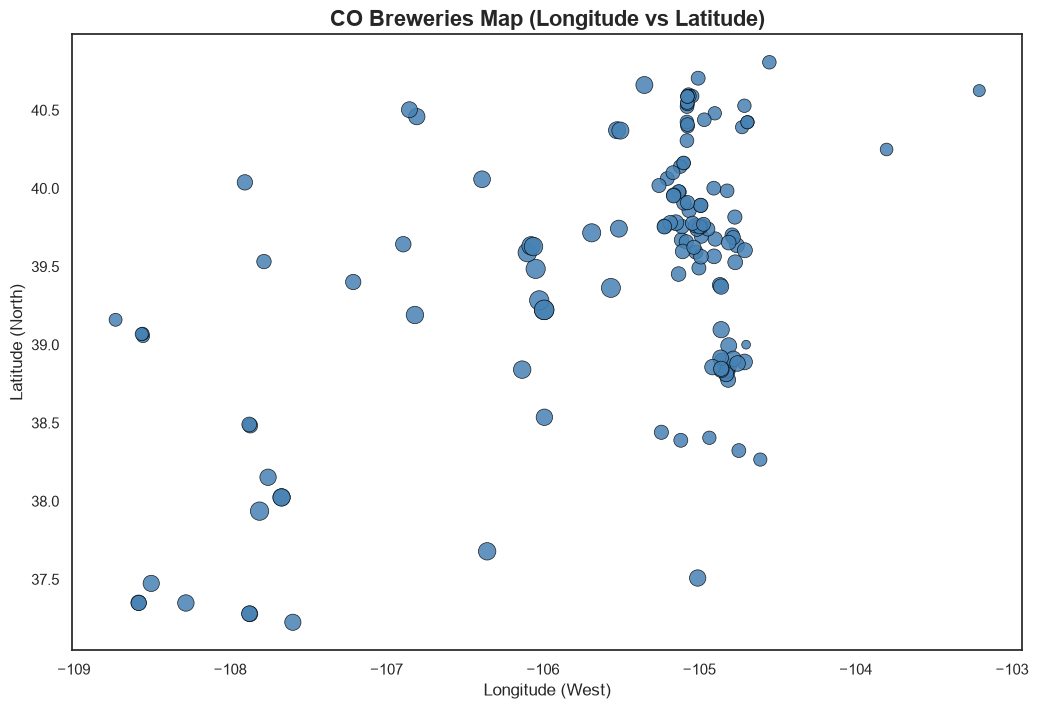

In [9]:
plt.figure(figsize=(14, 8))

valid_us = (
    (df['latitude'] >= 18.0) & 
    (df['latitude'] <= 72.0) & 
    (df['longitude'] >= -180.0) & 
    (df['longitude'] <= -65.0)
)

df_valid = df[valid_us]


ax = sns.scatterplot(
    data=df_valid,
    x="longitude",
    y="latitude",
    color="steelblue",
    size="elevation",
    sizes=(40, 200),
    alpha=0.85,
    edgecolor="black",
    linewidth=0.5,
    legend=False,
)

plt.title(
    "CO Breweries Map (Longitude vs Latitude)", fontsize=16, fontweight="bold"
)
plt.xlabel("Longitude (West)", fontsize=12)
plt.ylabel("Latitude (North)", fontsize=12)

# contiguous US only
# plt.xlim(-128, -65)
# plt.ylim(24, 50)

# Make the map proportions look natural (aspect ratio adjustment)
ax.set_aspect("equal")

# Move the legend outside or clean it up if it gets too crowded with 50 states
# plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, ncol=2)
# plt.tight_layout()

plt.show()

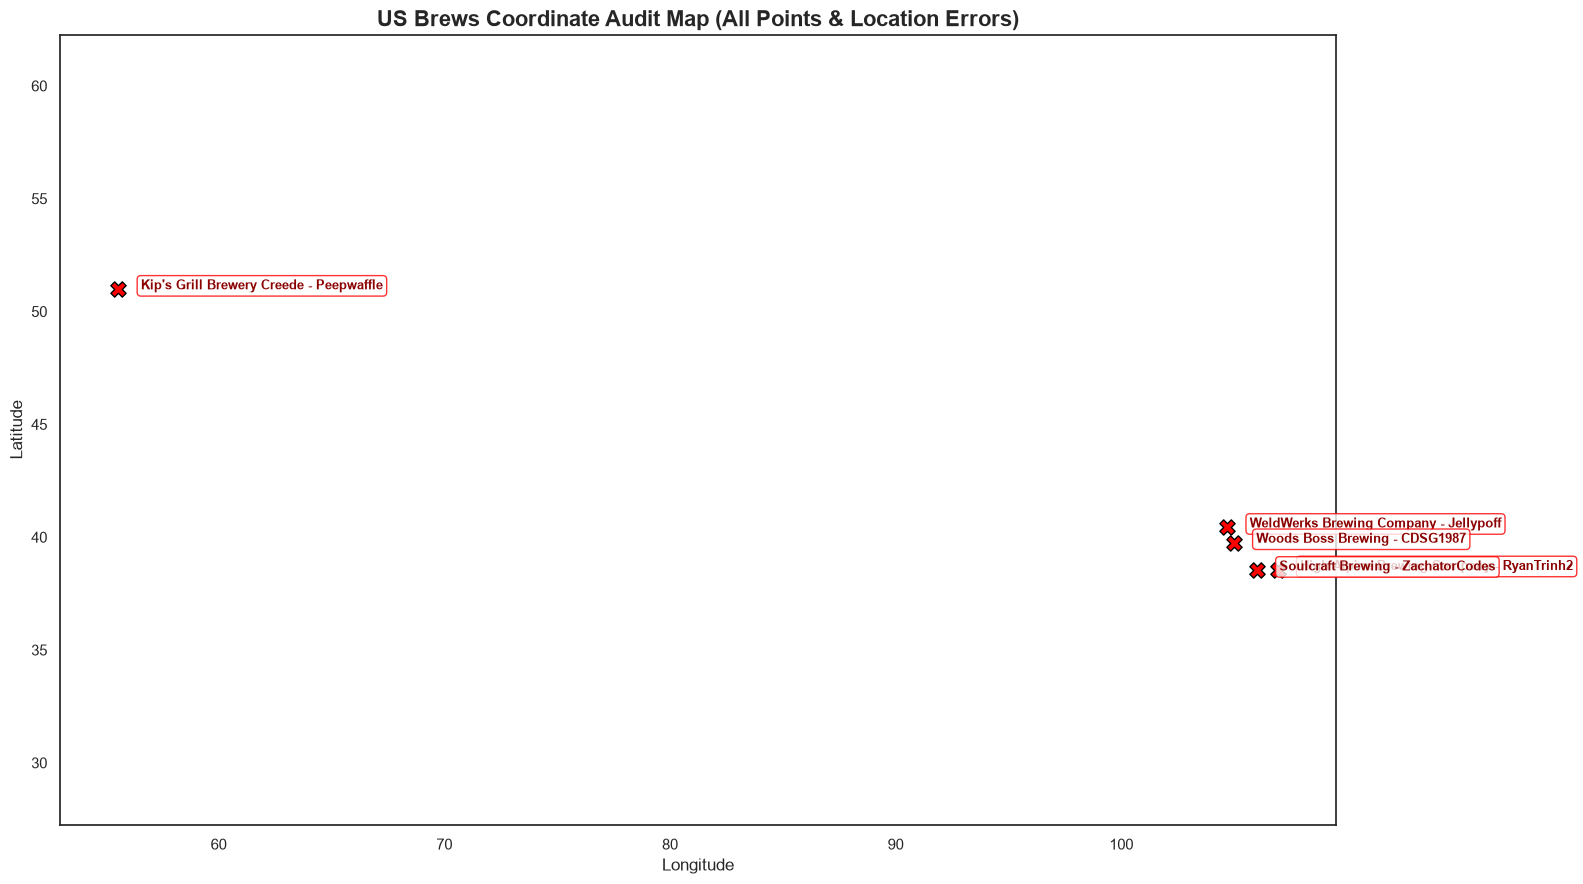

Audit Summary: 136 points within valid US bounds, 5 points flagged outside bounds.


In [13]:
plt.figure(figsize=(16, 9))

# 1. Define valid US geographic boundaries (inclusive of Alaska & Hawaii)
# Valid Lat: ~18 to 72, Valid Lon: ~-180 to -65 (Must be negative in the Western Hemisphere)
valid_us = (
    (df['latitude'] >= 24.0) & 
    (df['latitude'] <= 50.0) & 
    (df['longitude'] >= -125.0) & 
    (df['longitude'] <= -66.0)
)

df_valid = df[valid_us]
df_invalid = df[~valid_us]

# # 2. Plot valid US breweries
# sns.scatterplot(
#     data=df_valid,
#     x="longitude",
#     y="latitude",
#     color="steelblue",
#     alpha=0.7,
#     s=50,
#     edgecolor="none",
#     legend=False
# )

# 3. Plot out-of-bounds / error points
if not df_invalid.empty:
    sns.scatterplot(
        data=df_invalid,
        x="longitude",
        y="latitude",
        color="red",
        marker="X",
        s=120,
        edgecolor="black",
        linewidth=1,
        legend=False
    )
    
    # 4. Label out-of-bounds points with their region and brewery name
    for _, row in df_invalid.iterrows():
        label_text = f"{row['name']} - {row['id']}"
        plt.text(
            row['longitude'] + 1.0,  # Slight offset so text doesn't overlap the marker
            row['latitude'], 
            label_text, 
            fontsize=9, 
            fontweight='bold', 
            color='darkred',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8)
        )

plt.title("US Brews Coordinate Audit Map (All Points & Location Errors)", fontsize=16, fontweight="bold")
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)

# Keep proportions natural but let the limits expand if there are wild outliers
plt.gca().set_aspect('equal', adjustable='datalim')
plt.tight_layout()

plt.show()

print(f"Audit Summary: {len(df_valid)} points within valid US bounds, {len(df_invalid)} points flagged outside bounds.")

In [ ]:
# Print a structured text list of all invalid entries for quick auditing
if not df_invalid.empty:
    print("\n" + "="*80)
    print("FLAGGED OUT-OF-BOUNDS BREWERY ENTRIES:")
    print("="*80)
    for _, row in df_invalid.iterrows():
        print(f"• ID: {row.get('id', 'N/A')} | "
              f"Team: {row.get('team', 'N/A')} | "
              f"Brewery: {row.get('name', 'N/A')} | "
              f"Lat: {row.get('latitude')} | "
              f"Long: {row.get('longitude')} | "
              f"Elevation: {row.get('elevation', 'N/A')} ft.")
    print("="*80)


FLAGGED OUT-OF-BOUNDS BREWERY ENTRIES:
• ID: RyanTrinh2 | Team: t20 | Brewery: High Alpine Brewing Company | Lat: 38.5447 | Long: 106.927 | Elevation: 7706m
• ID: Jellypoff | Team: t25 | Brewery: WeldWerks Brewing Company | Lat: 40.428044 | Long: 104.690457 | Elevation: 4670m
• ID: Peepwaffle | Team: t37 | Brewery: Kip's Grill Brewery Creede | Lat: 50.9812 | Long: 55.5535 | Elevation: 2691m
• ID: ZachatorCodes | Team: t36 | Brewery: Soulcraft Brewing | Lat: 38.5246 | Long: 106.006 | Elevation: 7084m
• ID: CDSG1987 | Team: t20 | Brewery: Woods Boss Brewing | Lat: 39.75082 | Long: 104.98439 | Elevation: 5220m
